In [21]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import sys
sys.path.append("/ihome/ylee/yiz133/Code/Data processing/functions")
import importlib
import mdata_utils

In [22]:
# when functions changed
importlib.reload(mdata_utils)

<module 'mdata_utils' from '/ihome/ylee/yiz133/Code/Data processing/functions/mdata_utils.py'>

# GEX

In [23]:
data_path = "/ix1/ylee/Yifan_Zhang/Code_data/data_EAE/anndata"
mdata_ori = mu.read(data_path + "/all_Common.h5mu")

In [31]:
mdata = mdata_ori.copy()
mdata['gex'].obs.rename(columns = {"mouse_id":"sample_id"}, inplace=True)
mdata = mdata[mdata.obs['manual_cell_type'].isin(['CD4+ T', 'CD8+ T', 'Treg'])]
mdata

View of MuData object with n_obs × n_vars = 43562 × 33708
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'percent.mt', 'integrated_nn_res.2', 'seurat_clusters', 'level_2_clusters', 'manual_cell_type', 'run_num', 'sample'
  2 modalities
    gex:	43562 x 33708
      obs:	'sample_id', 'date', 'tissue', 'sample', 'mouse_BC'
    airr:	43562 x 0
      obsm:	'airr'

In [32]:
mdata['gex'].obs['tissue'] = (mdata['gex'].obs['tissue'].replace({'CN': 'CNS', 'SP': 'Spleen'}))
mdata['gex'].obs['tissue']

AAGGTGTAGCCCAACG-1_0516_CNS       CNS
AAGTAGCAGATAGGCG-1_0516_CNS       CNS
AAGTATACACCCAGTA-1_0516_CNS       CNS
AAGTTTGGTGGAACCC-1_0516_CNS       CNS
AATCTAGGTCAAACGT-1_0516_CNS       CNS
                                ...  
GTTGTGGGTGGAGCGA-1_0605_SPL    Spleen
GTTGTGGGTGGATCGC-1_0605_SPL    Spleen
GTTGTGGGTGGCTGTA-1_0605_SPL    Spleen
GTTGTGGGTGTCCCTG-1_0605_SPL    Spleen
GTTGTGGGTGTTACCC-1_0605_SPL    Spleen
Name: tissue, Length: 43562, dtype: category
Categories (2, object): ['CNS', 'Spleen']

In [33]:
%cd "/ix1/ylee/Yifan_Zhang/Code_data/external/GSE1 LEE"

/ix1/ylee/Yifan_Zhang/Code_data/external/GSE1 LEE


In [34]:
mdata.obs['GSE'] = 'LEE'
mdata.obs['GSM'] = np.where(mdata['gex'].obs['date'] == '0516', '0516', '0605')
mdata.obs['condition'] = 'EAE'


In [35]:
mdata = mdata_utils.pp_EAE(mdata, celltype_score = 0.4, cellstate_score = 0.4, topN_variable = None)

In [36]:
print(mdata['gex'].obs['cell_type'].value_counts())
print(mdata['gex'].obs['state'].value_counts())

cell_type
CD8     12891
CD4     11956
Treg     5492
Th17      736
Name: count, dtype: int64
state
Activation    6521
IFN_stim      2426
Exhaust       1064
Mem_Naive      502
Name: count, dtype: int64


# TCR

In [37]:
# mdata = mdata_ori.copy()
mdata['airr'].obs['sample_id'] = mdata['gex'].obs['sample_id']

ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only", within_group = 'sample_id')

meta_airr = ir.get.airr(mdata['airr'], ["cdr3_aa", "v_call", "j_call"] ,  ('VJ_1', 'VDJ_1'))

df2_filtered = meta_airr.loc[:, ~meta_airr.columns.isin(mdata.obs.columns)]
mdata.obs = mdata.obs.join(df2_filtered)
mdata.update()

# mdata.obs = mdata.obs.reindex(mdata.mod['gex'].obs.index)
ir.tl.clonal_expansion(mdata)


In [38]:
count = (mdata['airr'].obs['clone_id_size'] == 1).sum()
print(count)

37252


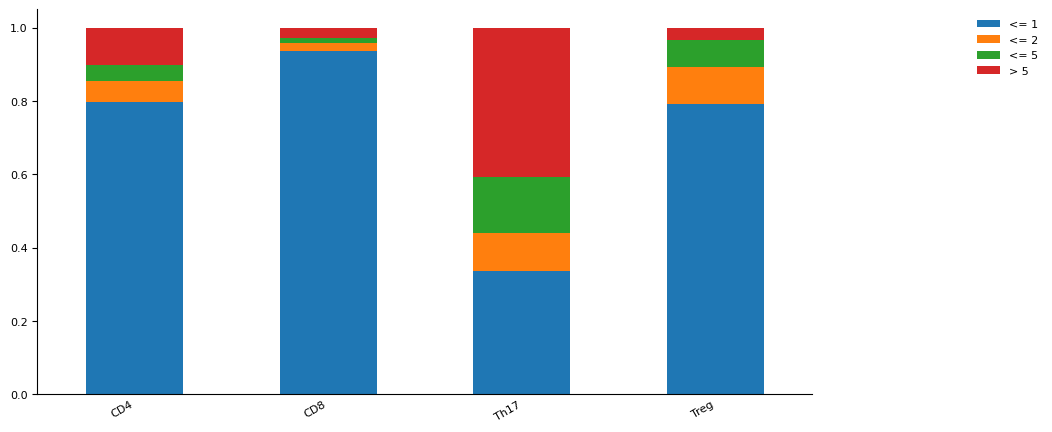

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby="cell_type",  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

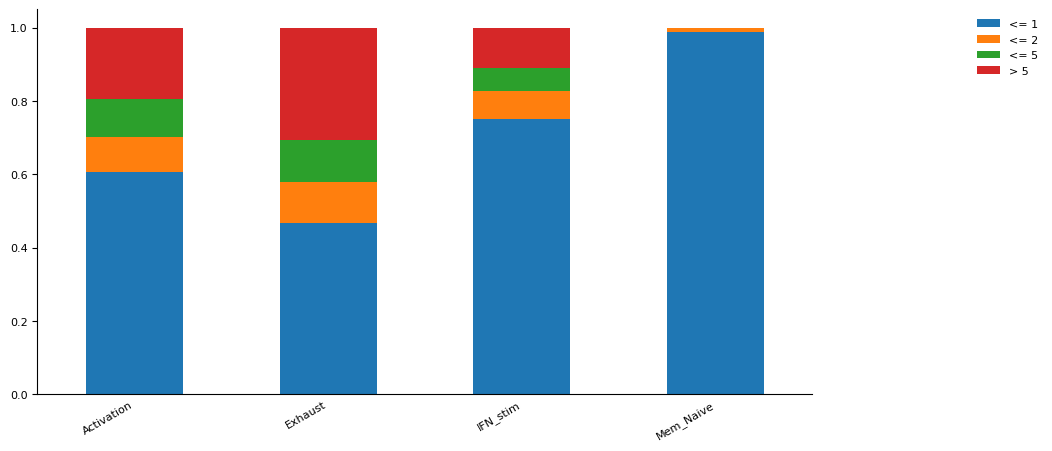

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby="state",  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

In [41]:
mdata

MuData object with n_obs × n_vars = 43562 × 14616
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'percent.mt', 'integrated_nn_res.2', 'seurat_clusters', 'level_2_clusters', 'manual_cell_type', 'run_num', 'sample', 'GSE', 'GSM', 'condition', 'state', 'cell_type', 'sample_id', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call'
  2 modalities
    gex:	43558 x 14616
      obs:	'sample_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      uns:	'log1p'
    airr:	43562 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'

In [42]:
# mdata.write('yz_processed.h5mu')
# mdata.write('yz_processed_allGenes_annotateByRef.h5mu')
mdata.write('yz_processed_allGenes_annotateByScore.h5mu')

In [43]:
aa

NameError: name 'aa' is not defined

In [ ]:
sc.pp.pca(mdata["gex"], svd_solver="arpack", n_comps=50)
sc.pp.neighbors(mdata["gex"], n_neighbors = 50)
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0)
sc.pl.umap(mdata["gex"], color=['cell_type', 'state'])